# Spatial Proteomics analysis (MACSima)

## 1. Read in the data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from spatialdata import read_zarr

import harpy as hp

# sdata = hp.datasets.macsima_colorectal_carcinoma(subset=False)

sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr")

In [ ]:
# list all channel names
import re

channels = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data


def normalize_channel_name(channel: str) -> str:
    match = re.match(r"^\d+_(.*?)_\d+_", channel)
    if match is None:
        return channel
    return match.group(1)


normalized_channels = [normalize_channel_name(ch) for ch in channels]

normalized_channels

sdata.set_channel_names(
    element_name="REAscreen_IO_CRC", channel_names=normalized_channels, write=True
)

In [ ]:
hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

array(['DAPI', 'CD279', 'Bcl 2', 'CD209', 'FoxP3', 'CD8a', 'CD44', 'p53',
       'CD138', 'CD45', 'CD15', 'Collagen I', 'CD274', 'Cytokeratin 7',
       'CD223', 'PCNA', 'CD163', 'CD11b', 'CD56', 'CD45RB', 'CD14',
       'CD107a', 'CD4', 'Cytokeratin 14', 'Ki 67', 'CD107b', 'CD31',
       'CD45RA', 'CD38', 'CD66', 'Cleaved PARP1', 'Mast Cell Tryptase',
       'CD66b', 'Podoplanin', 'CD20 Cytoplasmic', 'CD134', 'CD16', 'CD1c',
       'CD68', 'Actin', 'CD79a', 'Cytokeratin 20', 'CD45RO', 'CD11c',
       'Vimentin', 'CD3', 'CD324', 'HLA ABC', 'CD57', 'Cytokeratin 5',
       'CD204', 'Cytokeratin 8', 'MART 1', 'Cytokeratin 19',
       'Melanocyte PMEL', 'Cytokeratin', 'HLA DR', 'beta Catenin',
       'beta Actin', 'CD326', 'Cytokeratin HMW', 'Calponin'], dtype='<U18')

### 1.1 MACSima reader

For the summer school, we use an already constructed `SpatialData` object so that we can focus on the analysis workflow rather than the raw data conversion step.

Harpy provides a MACSima reader, [`hp.io.macsima`](https://harpy.readthedocs.io/en/latest/generated/harpy.io.macsima.html#harpy.io.macsima), which reads the data exported from MACS iQ View and can be used to construct a `SpatialData` object directly from the exported dataset.

### 1.2 QC

We recommend doing this interactively first, e.g. via napari-harpy.

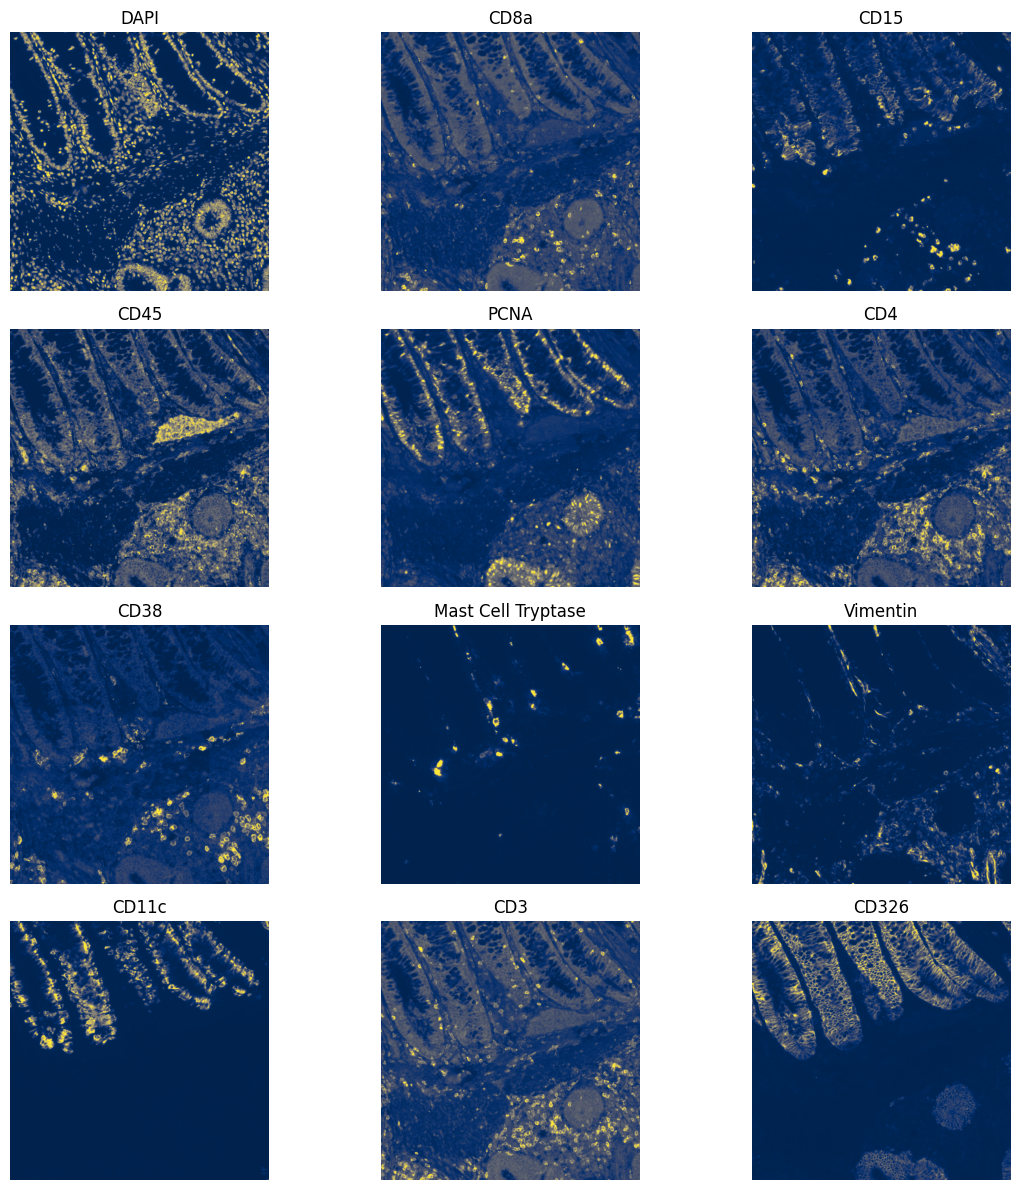

In [20]:
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
_image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]


se = hp.im.get_dataarray(sdata, element_name=_image_name)
channels = se.c.data

for _ax, _channel in zip(axes.flatten(), _channels_to_visualize, strict=False):
    # normalization parameters for visualization (underlying image not changed)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {
        "cmap": "cividis",
        "norm": norm,
        "scale": "scale1",
    }  # pass scale for faster plotting, but at lower resolution
    show_kwargs = {"title": _channel, "colorbar": False}
    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )
    # frameless figure
    _ax.axis("off")

plt.tight_layout()
plt.show()

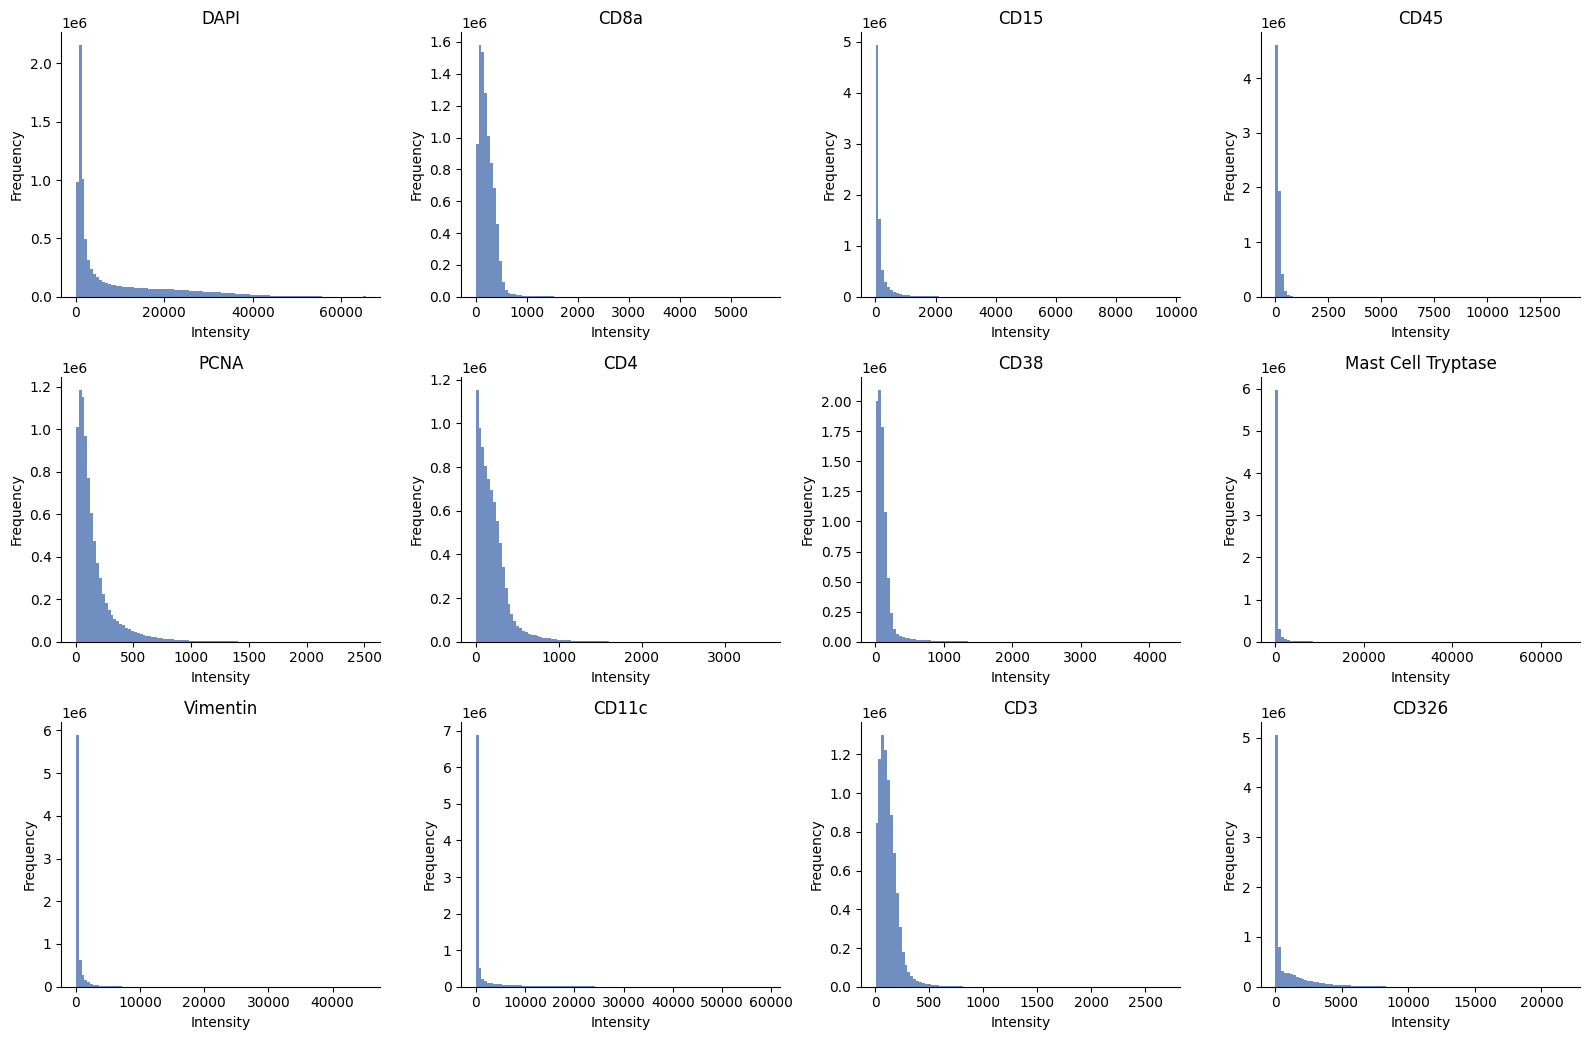

In [21]:
ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

## 2. QC and annotations of ROIs and artifacts in Qupath
Qupath is open source software for bioimage analysis. It has some really nice tools for annotating regions of interest and artifacts in images. We will use these for our dataset and add the results to the SpatialData object.

1. If necessary, install QUpath (v.0.5.1) using this [link](https://qupath.github.io/).
2. Open Qupath and click `Create project` in the top left corner.
3. Create a new empty folder for the project and click `Select Folder`.
4. You would normally add images to a project by going to `Add images` and providing the image paths. However, this would result in the images being added separately, and we would prefer a merged image containing all channels. To do this, we will use the `read_multichannel_qupath.groovy` script. To run it, go to `Automate`, `Script Editor`, `File`, `Open`, and select the script. In the Qupath script editor, change the folderPath argument to the folder containing the MACSima images and click `Run`. This should add all images to the project as a single image.
5. Explore the image by going to `Brightness & contrast`, select the channels you want to visualize and adjust the settings to improve the visualization.

### 2.1 QC image channels

<b>Excercise</b>:
- Create a python list of which channels you would consider successful and a list for the channels you believe failed. Since we're not experts in this tissue, we'll aim for removing the channels with obvious flaws (note that this is subjective and very dependent on how well you know the underlying biology and expected staining patterns for the biomarkers).

<details> 
<summary>Click to reveal the solution</summary>

```python

successful_channels = [
    "DAPI",
    "Bcl 2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki 67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved PARP1",
    "Mast Cell Tryptase",
    "CD20 Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin 20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA ABC",
    "CD57",
    "CD204",
    "MART 1",
    "Melanocyte PMEL",
    "Cytokeratin 19",
    "Cytokeratin",
    "HLA DR",
    "beta Catenin",
    "beta Actin",
    "CD326",
    "Calponin",
]

failed_channels = [
    "CD209",  # Uneven illumination
    "CD279",  # Uneven illumination
    "CD44",  # Uneven illumination
    "p53",  # Uneven illumination
    "Cytokeratin 7",  # Uneven illumination
    "CD223",  # Very bright (saturating) artifact
    "Cytokeratin 14",  # Uneven illumination
    "CD45RA",  # Uneven illumination
    "CD66",  # Very bright (saturating) artifact
    "CD134",  # Uneven illumination
    "Cytokeratin 5",  # Uneven illumination
    "Cytokeratin 8",  # Uneven illumination
    "Cytokeratin HMW",  # Uneven illumination
]


In [14]:
successful_channels = [
    "DAPI",
    "Bcl 2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki 67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved PARP1",
    "Mast Cell Tryptase",
    "CD20 Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin 20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA ABC",
    "CD57",
    "CD204",
    "MART 1",
    "Melanocyte PMEL",
    "Cytokeratin 19",
    "Cytokeratin",
    "HLA DR",
    "beta Catenin",
    "beta Actin",
    "CD326",
    "Calponin",
]

failed_channels = [
    "CD209",  # Uneven illumination
    "CD279",  # Uneven illumination
    "CD44",  # Uneven illumination
    "p53",  # Uneven illumination
    "Cytokeratin 7",  # Uneven illumination
    "CD223",  # Very bright (saturating) artifact
    "Cytokeratin 14",  # Uneven illumination
    "CD45RA",  # Uneven illumination
    "CD66",  # Very bright (saturating) artifact
    "CD134",  # Uneven illumination
    "Cytokeratin 5",  # Uneven illumination
    "Cytokeratin 8",  # Uneven illumination
    "Cytokeratin HMW",  # Uneven illumination
]

In [3]:
from napari_harpy import Interactive

Interactive(sdata)

### 2.2 Annotate artifacts

1. Open the `Bcl 2 (C3)` channel and annotate the acquisition bleaching regions. Since these are straight lines, you can use the rectangle annotation to annotate all the segments and subsequently merge the annotation by going to `Objects`, `Annotations...`, `Merge selected`. Rename the merged annotation to `acquisition_bleaching` by right-clicking on the annotation in the `Annotations` tab and going to `Set properties`.

2. Open the `DAPI (C1)` channel. In other datasets, we may find some out-of-focus regions, tissue-folds, etc that we could annotate. In this dataset, there is a small very bright region at the top right of the tissue. Annotate it using either the polygon annotation tool or the magic brush, merge any annotation objects you create and rename the merged object `bright_artifact`.

3. Export the annotations. Select all artifact annotations and go to `File`, `Export objects as GeoJSON` and set to `Selected objects` and `Compression` to None. Click `OK` and set the file name to `artifacts.geojson`.

### 2.3 Annotate ROIs

1. Now, pick a region that looks of interest to you, annotate it and label it `ROI`. Select it and export the GeoJSON as `ROI.geojson.`

### 2.4 Add annotations to sdata


TODO -> update these cells

In [ ]:
import geopandas as gpd

path_to_artifacts_GeoJSON = (
    r"d:\example_data_MACSima\REAscreen_IO_CRC\Qupath\artifacts.geojson"
)
path_to_ROI_GeoJSON = r"d:\example_data_MACSima\REAscreen_IO_CRC\Qupath\ROI.geojson"

gdf_artifacts = gpd.read_file(path_to_artifacts_GeoJSON)
sdata = hp.sh.add_shapes(
    sdata, input=gdf_artifacts, output_shapes_name="artifacts", overwrite=True
)

gdf_ROI = gpd.read_file(path_to_ROI_GeoJSON)
sdata = hp.sh.add_shapes(sdata, input=gdf_ROI, output_shapes_name="ROI", overwrite=True)

sdata

In [ ]:
# Inspect artifacts shapes layer
sdata.shapes["artifacts"]

In [ ]:
# Plot artifacts layer
hp.pl.plot_shapes(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="artifacts",
)

In [ ]:
# Inspect ROI shapes layer
sdata.shapes["ROI"]

In [ ]:
# Plot ROI layer
hp.pl.plot_shapes(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="ROI",
)

## 3. Segmentation 

### 3.1 Create subset of segmentation channels

In [18]:
segmentation_channels = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "HLA ABC",
    "CD326",
]

se = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC")
arr = se.sel(c=segmentation_channels).data
arr

dask.array<getitem, shape=(13, 3000, 3000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>

In [ ]:
from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=arr,
    output_image_name="REAscreen_IO_CRC_segmentation_channels",
    c_coords=segmentation_channels,
    transformations=get_transformation(sdata["REAscreen_IO_CRC"], get_all=True),
    scale_factors=[2, 2, 2, 2],
    overwrite=True,
)

2026-05-26 13:18:33.180 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels'


In [23]:
sdata["REAscreen_IO_CRC_segmentation_channels"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 13, y: 3000, x: 3000)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
│         * x        (x) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
│       Data variables:
│           image    (c, y, x) uint16 234MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 13, y: 1500, x: 1500)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 12kB 1.0 3.0 5.0 7.0 ... 2.995e+03 2.997e+03 2.999e+03
│         * x        (x) float64 12kB 1.0 3.0 5.0 7.0 ... 2.995e+03 2.997e+03 2.999e+03
│       Data variables:
│           image    (c, y, x) uint16 58MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 13, y: 750, x: 750)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 6kB 2.0 6.0 10.0 14.0 ... 2.99e+03 2.994e+03 2.998e+03
│         * x        (x) float64 6kB 2.0 6.0 10.0 14.0 ... 2.99e+03 2.994e+03 2.998e+03
│       Data variables:
│           image    (c, y, x) uint16 15MB dask.array<chunksize=(1, 750, 750), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 13, y: 375, x: 375)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 3kB 4.0 12.0 20.0 28.0 ... 2.98e+03 2.988e+03 2.996e+03
│         * x        (x) float64 3kB 4.0 12.0 20.0 28.0 ... 2.98e+03 2.988e+03 2.996e+03
│       Data variables:
│           image    (c, y, x) uint16 4MB dask.array<chunksize=(1, 375, 375), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 13, y: 187, x: 187)
        Coordinates:
          * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
          * y        (y) float64 1kB 8.021 24.06 40.11 ... 2.96e+03 2.976e+03 2.992e+03
          * x        (x) float64 1kB 8.021 24.06 40.11 ... 2.96e+03 2.976e+03 2.992e+03
        Data variables:
            image    (c, y, x) uint16 909kB dask.array<chunksize=(1, 187, 187), meta=np.ndarray>

In [ ]:
# Normalize images based on lower and upper percentile

# @Julien - > I would not do this quantile normalization, instanseg already does this internally. Or is there specific reason we should do it ?
# sdata = hp.im.normalize(
#    sdata,
#    image_name="REAscreen_IO_CRC_segmentation_channels",
#    output_image_name="REAscreen_IO_CRC_segmentation_channels_norm",
#    q_min=20.0,
#    q_max=99.9,
#    overwrite=True,
# )


# Perform min max filtering
sdata = hp.im.min_max_filtering(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    size_min_max_filter=55,
    overwrite=True,
)

# Perform contrast enhancement using CLAHE
sdata = hp.im.enhance_contrast(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    contrast_clip=3.5,
    chunks=(1, 2048, 2048),
    overwrite=True,
)

2026-05-26 13:33:37.627 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({'size_min_max_filter': 55}/<function min_max_filtering.<locals>._apply_min_max_filter at 0x3518e1260>). Specifying z-slices ([0]).
2026-05-26 13:33:37.628 | INFO     | harpy.image._map:_precondition:345 - 'combine_c' is False, but not all channels spefified in 'fn_kwargs'/'func' ({np.int64(0): {'size_min_max_filter': 55}}/{np.int64(0): <function min_max_filtering.<locals>._apply_min_max_filter at 0x3518e1260>}). Specifying channels (['DAPI' 'CD8a' 'CD15' 'CD45' 'PCNA' 'CD4' 'CD38' 'Mast Cell Tryptase'
 'Vimentin' 'CD11c' 'CD3' 'HLA ABC' 'CD326']).
2026-05-26 13:33:38.013 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels_minmax'
2026-05-26 13:33:44.665 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'

In [28]:
from napari_harpy import Interactive

Interactive(sdata)

In [ ]:
from spatialdata.transformations import get_transformation

get_transformation(sdata["REAscreen_IO_CRC"], get_all=True)

{'global_1': Identity ,
 'global_1_micron': Scale (c, y, x)
     [1.   0.17 0.17]}

### 3.3 Nuclei and cell segmentation

In [22]:
import os

from instanseg import InstanSeg

# Call the function to download and extract the models

instanseg_fluorescence = InstanSeg(
    "fluorescence_nuclei_and_cells", verbosity=1, device="cpu"
)

# or load the model from a path
path_model = os.path.join(
    os.environ.get("INSTANSEG_BIOIMAGEIO_PATH"),
    "fluorescence_nuclei_and_cells/0.1.1/instanseg.pt",
)

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/utils/../bioimageio_models/, loading


In [34]:
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_nuclei_instanseg"],
    output_shapes_name=["shapes_nuclei_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="nuclei",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57736 instead
  warnings.warn(


http://127.0.0.1:57736/status
Segmenting nuclei:


2026-05-26 13:47:47.803 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in

In [1]:
from spatialdata import read_zarr

sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr")

no parent found for <ome_zarr.reader.Label object at 0x1225c79e0>: None


In [17]:
# Nuclei segmentation using Cellpose (only on DAPI channel)
# @ Julien -> should we not consider removing this, and instead only use instanseg for segmentation in this notebook?

from dask.distributed import LocalCluster, Client

from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=hp.im.get_dataarray(
        sdata, element_name="REAscreen_IO_CRC_segmentation_channels_clahe"
    ).data[0][None, ...],
    output_image_name="DAPI",
    c_coords=["DAPI"],
    transformations=get_transformation(
        sdata["REAscreen_IO_CRC_segmentation_channels_clahe"], get_all=True
    ),
    overwrite=True,
)

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

sdata = hp.im.segment(
    sdata,
    image_name="DAPI",
    model=hp.im.cellpose_callable,
    # parameters that will be passed to the callable _cellpose:
    pretrained_model="nuclei",
    device=device,
    diameter=45,
    flow_threshold=0.9,
    channels=[0, 0],
    cellprob_threshold=-3,
    output_labels_name="labels_nuclei_cellpose",
    output_shapes_name="shapes_nuclei_cellpose",
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58359 instead
  warnings.warn(


http://127.0.0.1:58359/status


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/dask/array/core.py:3013: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  return to_zarr(self, *args, **kwargs)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-05-26 14:04:18.479 | INF

In [19]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

In [23]:
# cell segmentation using instanseg
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_cells_instanseg"],
    output_shapes_name=["shapes_cells_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="cells",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58458 instead
  warnings.warn(
2026-05-26 14:08:09.722 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.


http://127.0.0.1:58458/status
Segmenting nuclei:


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/dask/array/core.py:3013: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  return to_zarr(self, *args, **kwargs)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targe

In [26]:
sdata

SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr
├── Images
│     ├── 'DAPI': DataArray[cyx] (1, 3000, 3000)
│     ├── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
│     ├── 'REAscreen_IO_CRC_image_segmentation_channels_minmax': DataArray[cyx] (13, 3000, 3000)
│     ├── 'REAscreen_IO_CRC_segmentation_channels': DataTree[cyx] (13, 3000, 3000), (13, 1500, 1500), (13, 750, 750), (13, 375, 375), (13, 187, 187)
│     ├── 'REAscreen_IO_CRC_segmentation_channels_clahe': DataArray[cyx] (13, 3000, 3000)
│     └── 'REAscreen_IO_CRC_segmentation_channels_minmax': DataArray[cyx] (13, 3000, 3000)
├── Labels
│     ├── 'labels_cells_instanseg': DataArray[yx] (3000, 3000)
│     ├── 'labels_nuclei_cellpose': DataArray[yx] (3000, 3000)
│     └── 'labels_nuclei_instanseg': DataArray[yx] (3000, 3000)
├── Shapes
│     ├── 'shapes_cells_instanseg': GeoDataFrame shape: (323

In [24]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

### 3.4 Align nucleus and cell segmentations

In [28]:
# Align the nucleus and cell segmentations (we'll use the cellpose nucleus segmentation since it outperformed Instanseg)
sdata = hp.im.align_labels(
    sdata,
    labels_name_1="labels_nuclei_cellpose",
    labels_name_2="labels_cells_instanseg",
    output_labels_name="labels_nuclei_cellpose_aligned",
    output_shapes_name="shapes_nuclei_cellpose_aligned",
    # chunks=2048,
    overwrite=True,
)
# This function aligns two label layers by examining the labels in labels_layer_1 and identifying their maximum overlap with labels in labels_layer_2.
# It then updates the labels of labels_layer_1 (i.e. "labels_nuclei_cellpose").
# If a label from labels_layer_1 has no overlap with a label from label_layer_2, the label in labels_layer_1 is set to zero (i.e. background).
# If two labels from labels_layer_1 overlap with the same label from labels_layer_2, they are effectively merged into the same new label.

/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/dask/array/core.py:3013: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  return to_zarr(self, *args, **kwargs)
2026-05-26 14:26:26.484 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-05-26 14:26:26.501 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_cellpose_aligned'
no parent found for <ome_zarr.reader.Label object at 0x357fedac0>: None
no parent found for <ome_zarr.reader.Label object at 0x36aad3560>: None
no parent found for <ome_zarr.reader.Label object at 0x36aad0650>: None
no parent found for <ome_zarr.reader.Label object at 0x36ab65490>: None
2026-05-26 14:26:28.110 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:338 - Finished vectorizing. Dissol

## 4. Cell properties

### 4.1 Cell intensities

In [92]:
hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").sel(c=successful_channels)

<xarray.DataArray 'image' (c: 49, y: 3000, x: 3000)> Size: 882MB
dask.array<getitem, shape=(49, 3000, 3000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U18 4kB 'DAPI' 'Bcl 2' 'CD8a' ... 'CD326' 'Calponin'
  * y        (y) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
  * x        (x) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
Attributes:
    transform:  {'global_1': Identity , 'global_1_micron': Scale (c, y, x)\n ...

In [ ]:
# from spatialdata import read_zarr

# sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr")

In [8]:
import harpy as hp

# first do quantile normalization:

pmin = 0.1
pmax = 99.9

channels = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

sdata = hp.im.normalize(
    sdata,
    image_name="REAscreen_IO_CRC",
    output_image_name="REAscreen_IO_CRC_normalized",
    p_min=len(channels) * [pmin],
    p_max=len(channels) * [pmax],
    internal_method="tdigest",
    overwrite=True,
)

2026-05-26 16:13:45.994 | INFO     | harpy.image._map:_precondition:359 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('DAPI'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD279'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('Bcl 2'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD209'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('FoxP3'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD8a'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD44'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('p53'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD138'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD45')

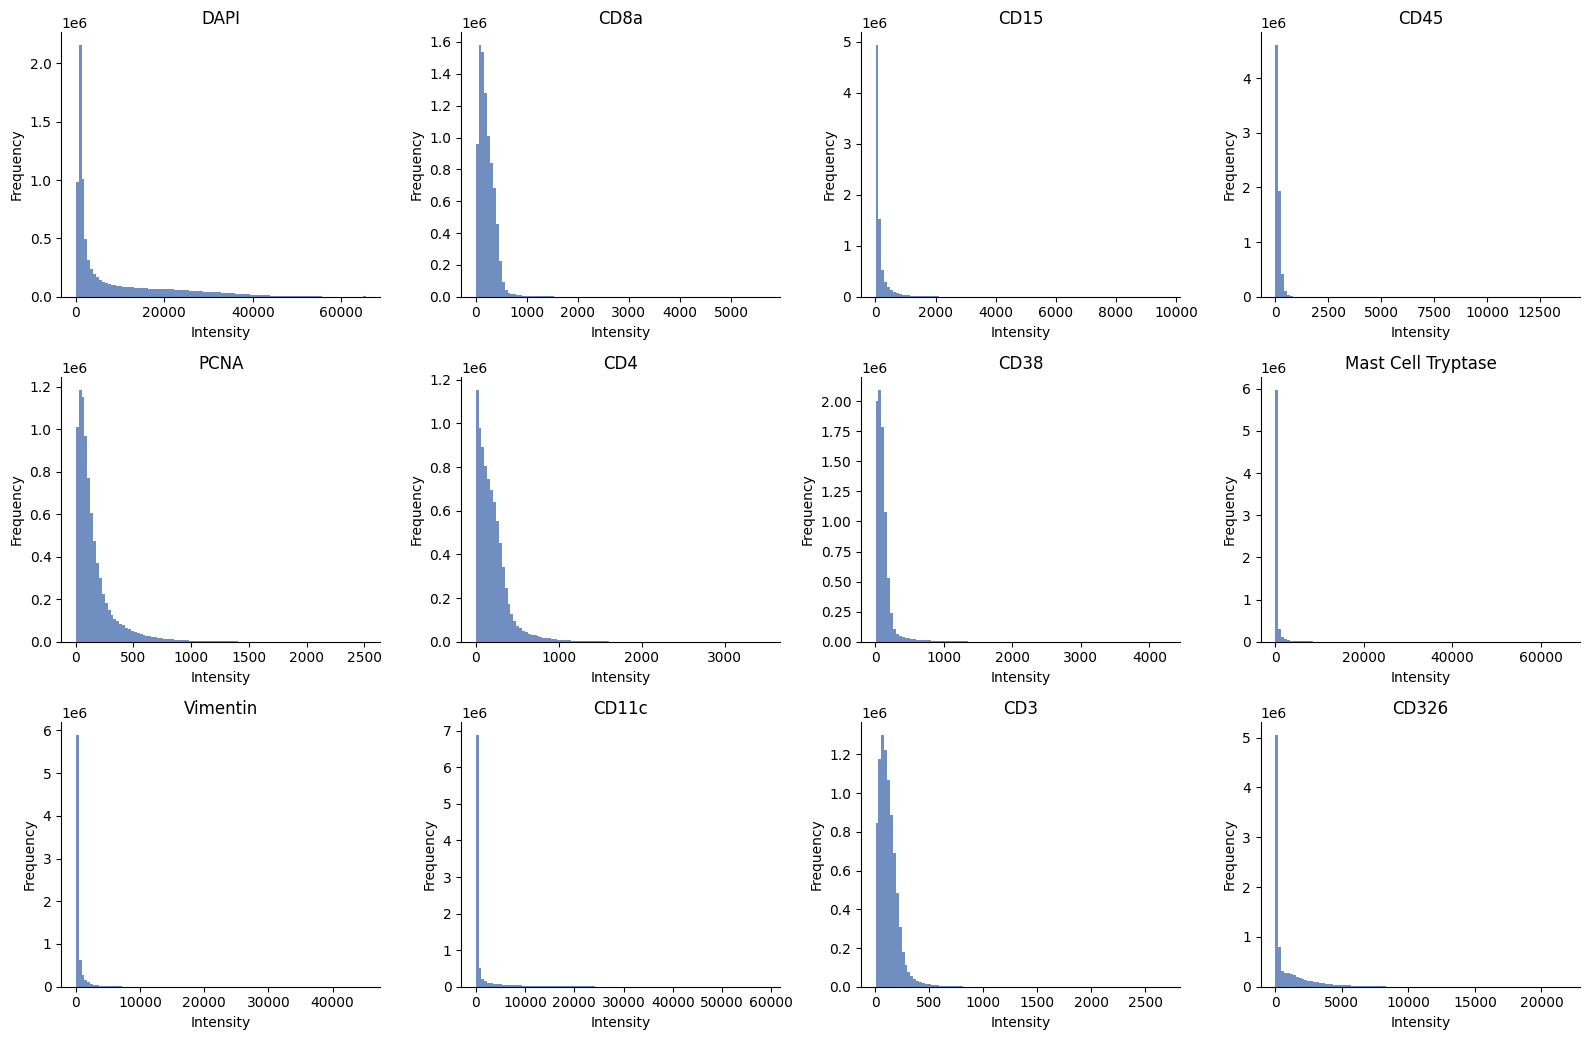

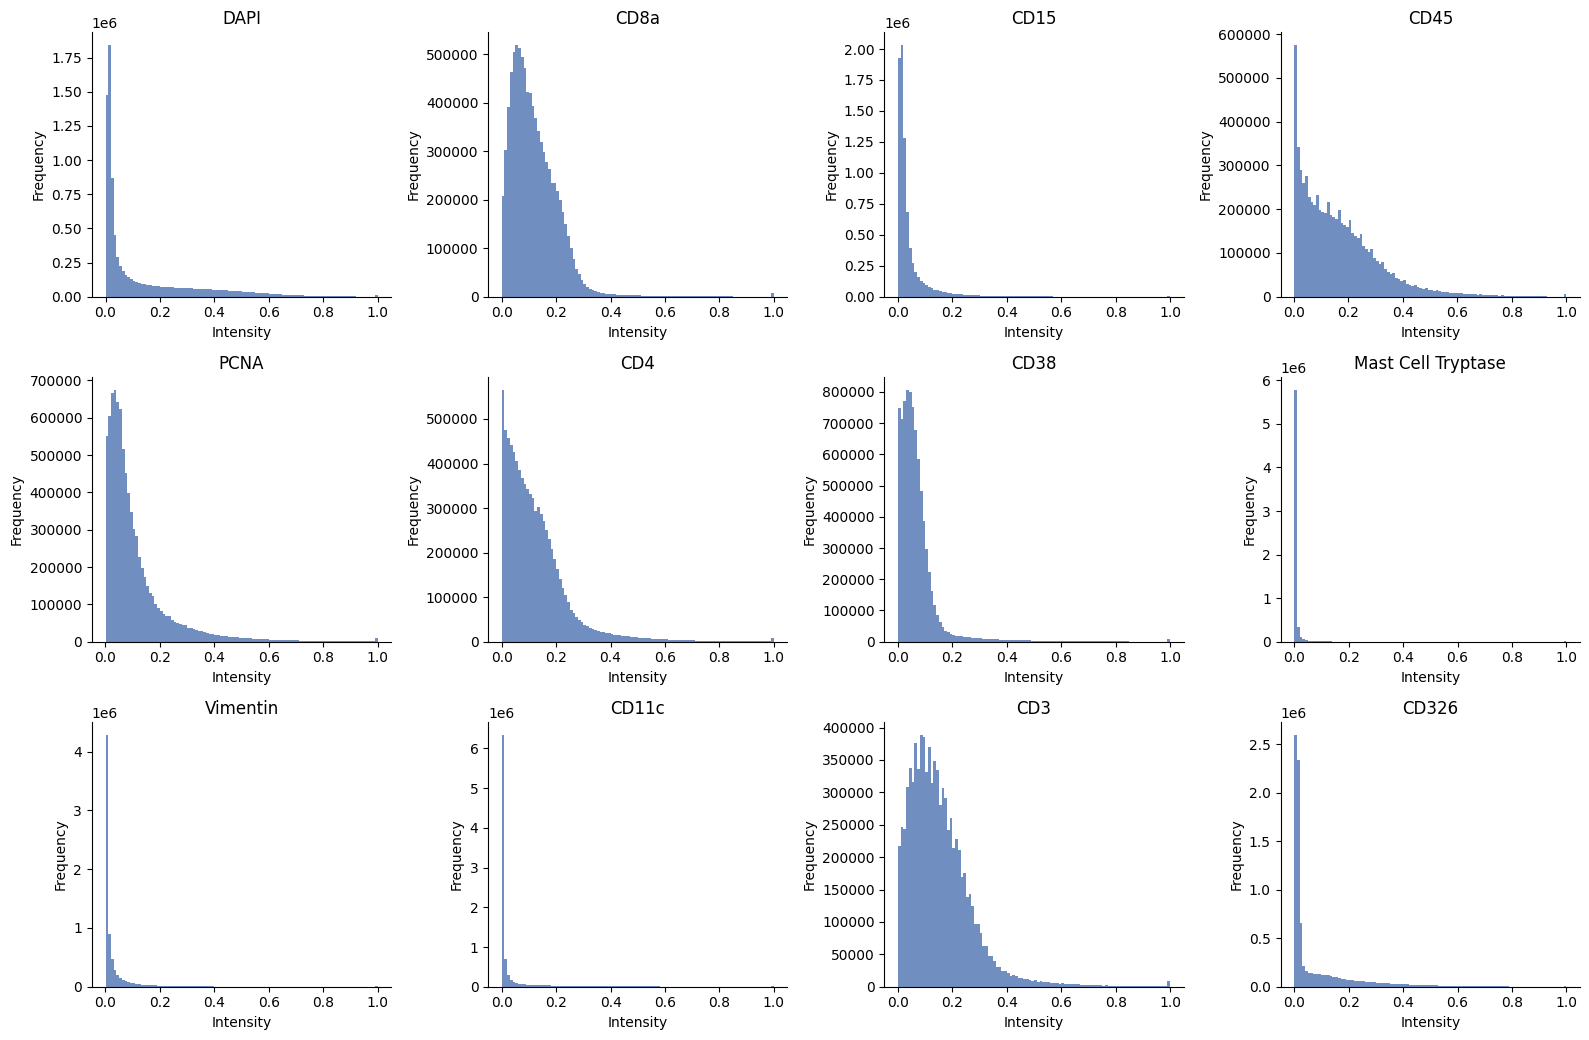

In [12]:
_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

In [15]:
# Calculate intensities for cell segmentations.
marker_channels = [channel for channel in successful_channels]

sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells",
    channels=marker_channels,
    mode="mean",  # When set to "sum", the total intensity for each channel will be added to `.X` of the table layer; if set to `"mean"`, it calculates the average intensity per channel.
    # obs_stats=["sum", "mean", "count", "var", "kurtosis", "skew", "max", "min"] # Stats that will be added to `.obs` of `output_layer`
    chunks=2048,
    to_coordinate_system="global_1",
    overwrite=True,
)

2026-05-26 16:17:53.973 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/table/_allocation_intensity.py:338: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  adata.obsm[spatial_key] = coordinates
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be 

In [23]:
# z-scoring before leiden clustering

sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    output_table_name="table_cells_z_scored",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)


2026-05-26 16:20:28.434 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  retur

In [24]:
microns_per_pixel = 0.17

sdata = hp.tb.add_regionprops(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    output_table_name="table_cells_z_scored",
    properties=["perimeter", "eccentricity", "convex_area", "area"],
    overwrite=True,
)

# convert to microns:
sdata["table_cells"].obs["perimeter"] = (
    sdata["table_cells"].obs["perimeter"] * microns_per_pixel
)
sdata["table_cells"].obs["convex_area"] = (
    sdata["table_cells"].obs["convex_area"] * microns_per_pixel**2
)

sdata["table_cells"].obs["area"] = (
    sdata["table_cells"].obs["area"] * microns_per_pixel**2
)
sdata["table_cells"].obs[["perimeter", "eccentricity", "convex_area", "area"]].head()

2026-05-26 16:20:51.057 | WARNING  | harpy.table._regionprops:add_regionprops:148 - Cell property 'perimeter' already exists in '.obs' attribute of table element 'table_cells_z_scored'. Skipping recomputation. Remove the column to trigger recalculation.
2026-05-26 16:20:51.058 | WARNING  | harpy.table._regionprops:add_regionprops:148 - Cell property 'eccentricity' already exists in '.obs' attribute of table element 'table_cells_z_scored'. Skipping recomputation. Remove the column to trigger recalculation.
2026-05-26 16:20:51.058 | WARNING  | harpy.table._regionprops:add_regionprops:148 - Cell property 'convex_area' already exists in '.obs' attribute of table element 'table_cells_z_scored'. Skipping recomputation. Remove the column to trigger recalculation.
2026-05-26 16:20:51.058 | WARNING  | harpy.table._regionprops:add_regionprops:148 - Cell property 'area' already exists in '.obs' attribute of table element 'table_cells_z_scored'. Skipping recomputation. Remove the column to trigger

,perimeter,eccentricity,convex_area,area
cells,,,,
105_labels_cells_instanseg_a57cae0b,3.771025,0.639923,0.892004,0.841892
129_labels_cells_instanseg_a57cae0b,0.346800,1.000000,0.011693,0.011693
133_labels_cells_instanseg_a57cae0b,5.104532,0.848078,1.250309,1.160107
141_labels_cells_instanseg_a57cae0b,3.847808,0.828831,0.735820,0.679026
145_labels_cells_instanseg_a57cae0b,3.992308,0.618995,0.808483,0.739161


,labels_name,total_instances,total_area_μm²,covered_area_μm²,covered_area_percentage
0,labels_cells_instanseg,3233,260100.0,126715.7492,48.718089


2026-05-26 16:21:06.242 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:162 - Calculating cell size for labels element 'labels_cells_instanseg'.
2026-05-26 16:21:06.361 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:166 - Converting cell area from pixels to square microns using microns_per_pixel=0.17.


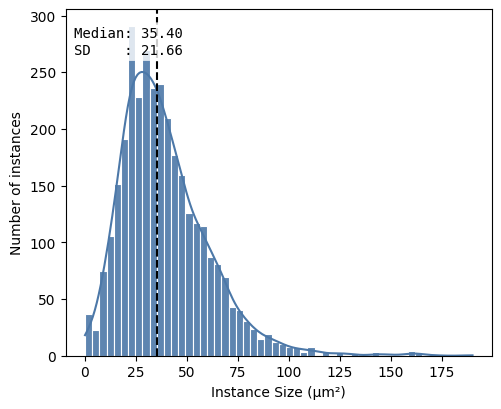

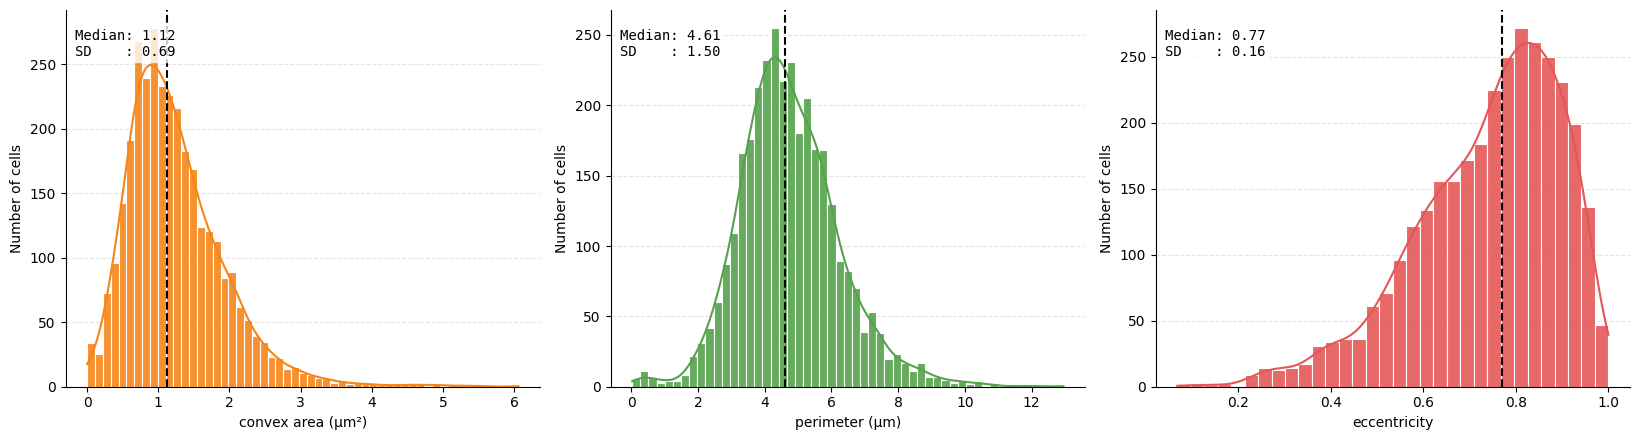

In [25]:
df = hp.qc.segmentation_coverage(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
)
display(df)
hp.qc.segmentation_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
)

metrics = (
    ("obs", "convex_area"),
    ("obs", "perimeter"),
    ("obs", "eccentricity"),
)

ax = hp.qc.metrics_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    display_column=["convex area (μm²)", "perimeter (μm)", "eccentricity"],
    color=[
        "#F58518",
        "#54A24B",
        "#E45756",
    ],
    metrics=metrics,
)

### 4.2 Filter segmentation masks based on size and artifacts

In [26]:
min_area_um2 = 10  # Minimum size of segmentation objects (in square micrometer).
max_area_um2 = 200  # Maximum size of segmentation objects (in square micrometer).

sdata["table_cells_z_scored"].obs["filter_on_size"] = (
    ~sdata["table_cells_z_scored"].obs["area"].between(10, 200)
).astype("category")


# @ Julien -> could you add similar logic for the artefacts. I.e. we annotate the Anndata table with a boolean column
# for the final filter we than simply combine all these boolean column, and filter the table.
# I prefer filtering the table than filtering a segmentation mask. As the AnnData table is an annotion of mask, so all info can live there.

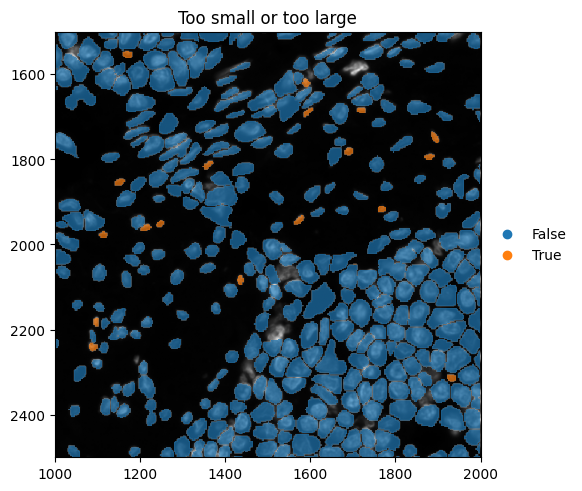

In [27]:
image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

ax = hp.pl.plot_sdata(
    sdata,
    image_name=image_name,
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    color="filter_on_size",
    crd=[1000, 2000, 1500, 2500],
    to_coordinate_system=to_coordinate_system,
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.7,
        "outline_alpha": 0.2,
    },
    show_kwargs={
        "title": "Too small or too large",
        "colorbar": False,
    },
)

In [28]:
# Now add the column contains nucleus.
sdata["table_cells_z_scored"].obs.head()

,cell_ID,fov_labels,perimeter,eccentricity,convex_area,area,filter_on_size,has_nucleus
cells,,,,,,,,
105_labels_cells_instanseg_a57cae0b,105,labels_cells_instanseg,22.182498,0.639923,30.8652,29.1312,False,True
129_labels_cells_instanseg_a57cae0b,129,labels_cells_instanseg,2.040000,1.000000,0.4046,0.4046,True,False
133_labels_cells_instanseg_a57cae0b,133,labels_cells_instanseg,30.026661,0.848078,43.2633,40.1421,False,True
141_labels_cells_instanseg_a57cae0b,141,labels_cells_instanseg,22.634163,0.828831,25.4609,23.4957,False,True
145_labels_cells_instanseg_a57cae0b,145,labels_cells_instanseg,23.484163,0.618995,27.9752,25.5765,False,False


In [29]:
import dask.array as da
import numpy as np

cell_labels_ids = da.unique(sdata["labels_cells_instanseg"].data).compute()
nuclei_labels_ids = da.unique(sdata["labels_nuclei_cellpose_aligned"].data).compute()

cell_without_nucleus_ids = np.setdiff1d(
    cell_labels_ids,
    nuclei_labels_ids,
)

cell_without_nucleus_ids

sdata["table_cells"].obs["has_nucleus"] = ~sdata["table_cells"].obs["cell_ID"].isin(
    cell_without_nucleus_ids
)
sdata["table_cells"].obs["has_nucleus"] = (
    sdata["table_cells"].obs["has_nucleus"].astype("category")
)

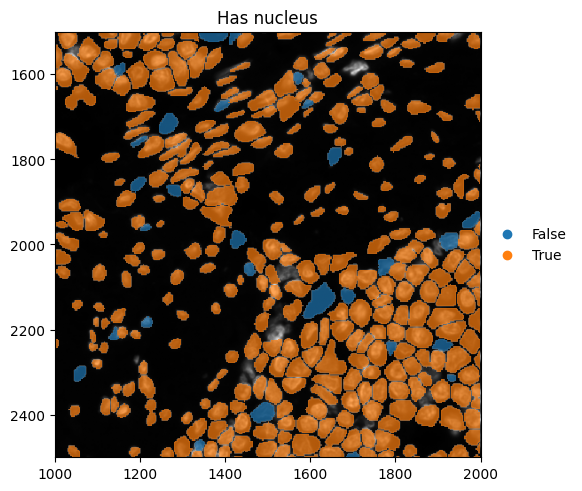

In [30]:
image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

ax = hp.pl.plot_sdata(
    sdata,
    image_name=image_name,
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    color="has_nucleus",
    crd=[1000, 2000, 1500, 2500],
    to_coordinate_system=to_coordinate_system,
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.7,
        "outline_alpha": 0.2,
    },
    show_kwargs={
        "title": "Has nucleus",
        "colorbar": False,
    },
)

In [88]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

2026-05-26 15:42:36.716 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:294 - No stored `has_nucleus_colors` palette found in `table.uns`; using the default categorical palette for viewer coloring.
2026-05-26 15:43:20.417 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:294 - No stored `has_nucleus_colors` palette found in `table.uns`; using the default categorical palette for viewer coloring.
2026-05-26 15:43:36.955 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:294 - No stored `has_nucleus_colors` palette found in `table.uns`; using the default categorical palette for viewer coloring.


Lets filter on size (you could also filter on other properties), and write the result to a new slot.

In [35]:
from spatialdata.models import TableModel

adata = sdata["table_cells_z_scored"]

spatialdata_attrs = adata.uns[TableModel.ATTRS_KEY]
region_key = spatialdata_attrs[TableModel.REGION_KEY_KEY]
instance_key = spatialdata_attrs[TableModel.INSTANCE_KEY]

mask = adata.obs["filter_on_size"].eq(False)

adata_filtered = adata[mask].copy()

sdata = hp.tb.add_table(
    sdata,
    adata=adata_filtered,
    output_table_name="table_cells_z_scored_filterd",
    region=list(adata_filtered.obs[region_key].unique()),
    instance_key=instance_key,
    region_key=region_key,
    overwrite=True,
)

/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 auto

In [37]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

2026-05-26 16:30:14.312 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:294 - No stored `filter_on_size_colors` palette found in `table.uns`; using the default categorical palette for viewer coloring.


/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 auto

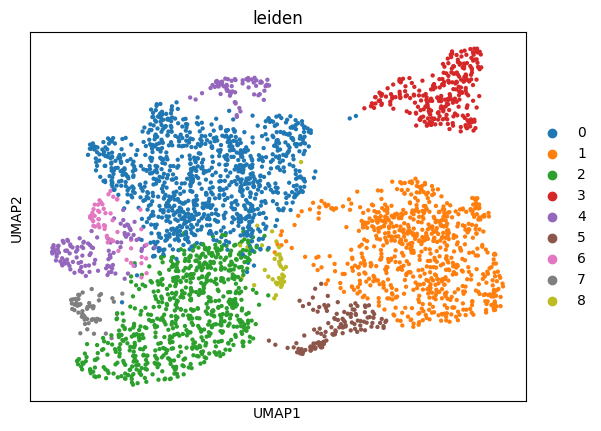

In [38]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored_filterd",
    output_table_name="table_cells_z_scored_filterd",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_cells_z_scored_filterd"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

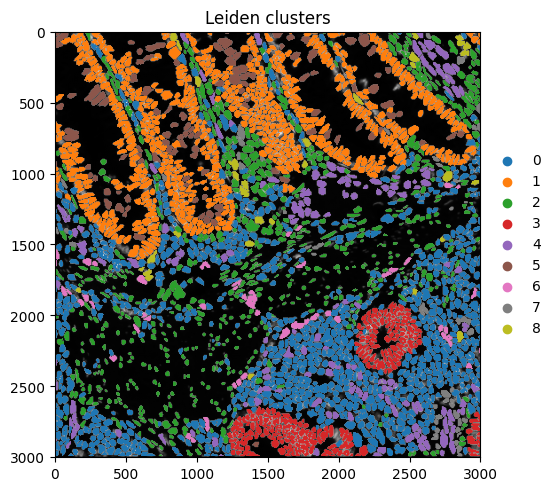

In [40]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    color="leiden",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

In [41]:
Interactive(sdata, widgets="viewer")

2026-05-26 16:35:47.291 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:312 - Using stored `leiden_colors` palette from `table.uns` for viewer coloring.


<Axes: >

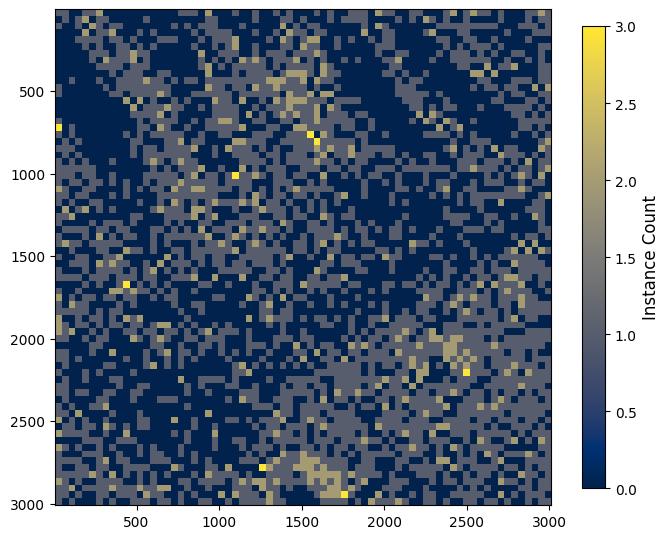

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

hp.pl.plot_instance_density(
    sdata,
    bin_size=7
    / 0.17,  # bin size in pixels if .obsm["spatial"] of the AnnData table "table_transcriptomics" is in pixels
    spatial_key="spatial",
    table_name="table_cells_z_scored_filterd",
    cmap="cividis",
    ax=ax,
)

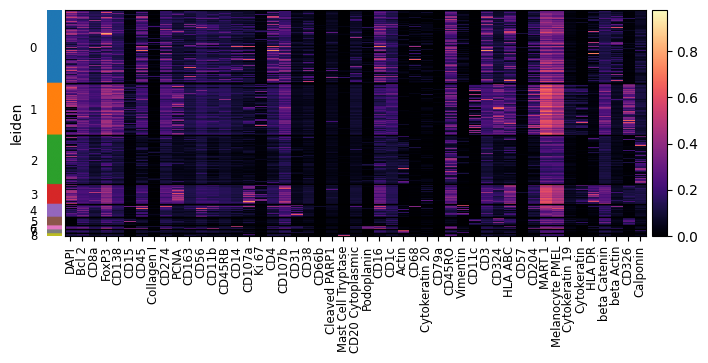

In [55]:
sc.pl.heatmap(
    sdata["table_cells_z_scored_filterd"],
    var_names=sdata["table_cells_z_scored_filterd"].var_names,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(8, 3),
    show_gene_labels=True,
)

2026-05-26 16:44:55.378 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'leiden') will be stored in 'sdata[table_cells_z_scored_filterd].uns[leiden_weighted_intensity]'.
2026-05-26 16:44:55.388 | WARNING  | harpy.table._cluster_intensity:cluster_intensity:94 - Key 'leiden_weighted_intensity' found in sdata[table_cells_z_scored_filterd].uns. Object at that location will be removed and recalculated.
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none

,leiden,DAPI,Bcl 2,CD8a,FoxP3,CD138,CD15,CD45,Collagen I,CD274,...,CD204,MART 1,Melanocyte PMEL,Cytokeratin 19,Cytokeratin,HLA DR,beta Catenin,beta Actin,CD326,Calponin
0,0,0.255094,0.248336,0.164536,0.278317,0.185414,0.022214,0.223435,0.026979,0.208265,...,0.135473,0.375611,0.343337,0.031415,0.004457,0.085473,0.140827,0.128385,0.022820,0.083757
1,1,0.277104,0.272344,0.195934,0.360780,0.318260,0.100166,0.193949,0.007856,0.228543,...,0.265616,0.533750,0.442642,0.098183,0.099881,0.023235,0.244505,0.068234,0.288656,0.102400
2,2,0.205719,0.178128,0.092538,0.148849,0.132229,0.016180,0.061026,0.016726,0.098348,...,0.039008,0.217328,0.213293,0.021565,0.002448,0.029885,0.114646,0.041867,0.022498,0.133008
3,3,0.309620,0.223314,0.214327,0.389848,0.207883,0.022231,0.206138,0.011080,0.262535,...,0.162302,0.578999,0.473899,0.093752,0.189777,0.266072,0.313332,0.070679,0.124186,0.124756
4,4,0.155916,0.248209,0.136198,0.286436,0.147776,0.127094,0.249947,0.019287,0.200602,...,0.138853,0.359935,0.378435,0.030812,0.004281,0.038153,0.156032,0.088287,0.016629,0.060266
5,5,0.037461,0.135463,0.092014,0.144679,0.150882,0.077140,0.053679,0.004492,0.097256,...,0.100890,0.248408,0.221631,0.051898,0.050393,0.011406,0.165164,0.031164,0.181093,0.048293
6,6,0.168457,0.217831,0.119473,0.240985,0.153990,0.031451,0.168403,0.050998,0.183500,...,0.129444,0.321860,0.300714,0.032761,0.003212,0.060710,0.126201,0.088208,0.016349,0.073833
7,7,0.173549,0.186252,0.091991,0.169270,0.116772,0.014619,0.075195,0.024810,0.105293,...,0.059406,0.245822,0.234846,0.021965,0.003693,0.017863,0.114375,0.049995,0.029932,0.124495
8,8,0.169295,0.200409,0.098109,0.177934,0.139779,0.018942,0.115300,0.018281,0.139385,...,0.071980,0.236872,0.248656,0.021499,0.002602,0.050653,0.114155,0.046211,0.021808,0.049430


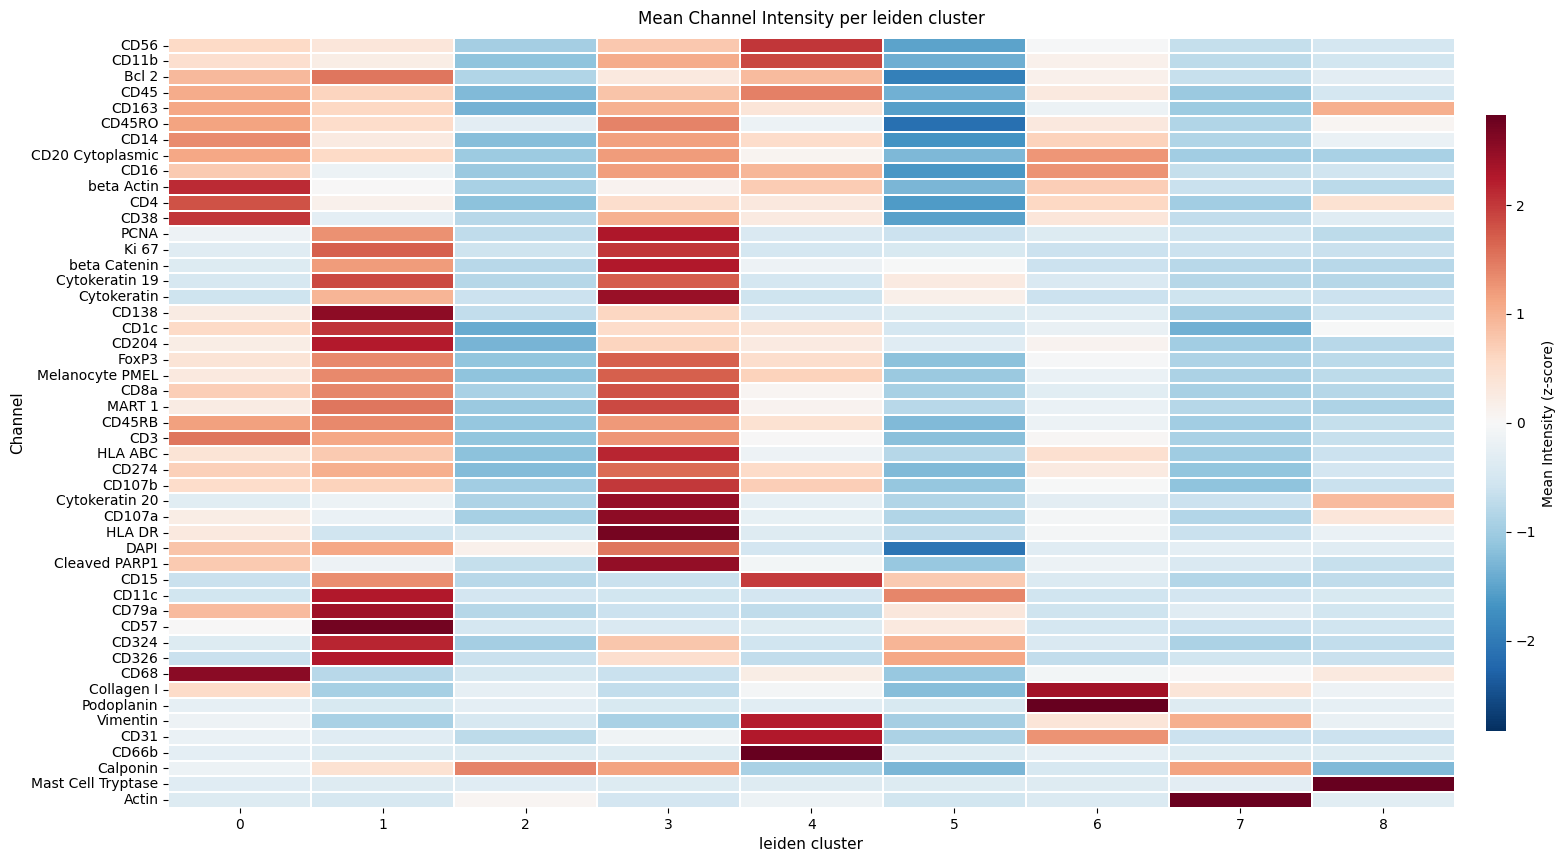

In [57]:
# calculate the mean itensity per leiden cluster
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity(
    sdata,
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells_z_scored_filterd",
    cluster_key="leiden",
    layer_mean_intensities="mean_counts",
    cluster_key_uns=f"{cluster_key}_weighted_intensity",
    overwrite=True,
)

display(sdata["table_cells_z_scored_filterd"].uns[f"{cluster_key}_weighted_intensity"])

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name="table_cells_z_scored_filterd",
    cluster_key="leiden",
    z_score=True,
    figsize=(20, 10),
)

In [ ]:
from spatialdata import read_zarr

sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr")
sdata

no parent found for <ome_zarr.reader.Label object at 0x149b4f3b0>: None
no parent found for <ome_zarr.reader.Label object at 0x149b4d130>: None
no parent found for <ome_zarr.reader.Label object at 0x149b29d90>: None
no parent found for <ome_zarr.reader.Label object at 0x14908c5c0>: None


SpatialData object, with associated Zarr store: /Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr
├── Images
│     ├── 'DAPI': DataArray[cyx] (1, 3000, 3000)
│     ├── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
│     ├── 'REAscreen_IO_CRC_image_segmentation_channels_minmax': DataArray[cyx] (13, 3000, 3000)
│     ├── 'REAscreen_IO_CRC_normalized': DataArray[cyx] (62, 3000, 3000)
│     ├── 'REAscreen_IO_CRC_segmentation_channels': DataTree[cyx] (13, 3000, 3000), (13, 1500, 1500), (13, 750, 750), (13, 375, 375), (13, 187, 187)
│     ├── 'REAscreen_IO_CRC_segmentation_channels_clahe': DataArray[cyx] (13, 3000, 3000)
│     └── 'REAscreen_IO_CRC_segmentation_channels_minmax': DataArray[cyx] (13, 3000, 3000)
├── Labels
│     ├── 'labels_cells_instanseg': DataArray[yx] (3000, 3000)
│     ├── 'labels_nuclei_cellpose': DataArray[yx] (3000, 3000)
│     ├── 'labels_nuclei_cellpose_aligned': DataArray[yx] (300

In [65]:
sdata["table_cells_z_scored_filterd"]

AnnData object with n_obs × n_vars = 3114 × 49
    obs: 'cell_ID', 'fov_labels', 'perimeter', 'eccentricity', 'convex_area', 'area', 'filter_on_size', 'has_nucleus', 'leiden', 'shapeSize'
    var: 'mean', 'std'
    uns: 'umap', 'spatialdata_attrs', 'leiden', 'rank_genes_groups', 'neighbors', 'leiden_weighted_intensity', 'leiden_colors'
    obsm: 'X_umap', 'spatial'
    layers: 'mean_counts'
    obsp: 'connectivities', 'distances'

## 5. Ilastik object classification

@ Julien -> we can replace with napari_harpy object classification. I can show you how it works, and then we can see if napari_harpy would still miss something. 
We can keep the Ilastik documentation as a reference, but then we move it to a seperate notebook, together with the pixel classification.

In [ ]:
from ilastik.sdata_to_ilastik import (
    export_h5,
    add_ilastik_to_sdata,
    assign_ilastik_cell_types,
    combine_ilastik_predictions,
)

### 5.1 Export images for Ilastik

In [ ]:
# Paths to export h5 files
img_layer_to_export = "REAscreen_IO_CRC_image"
path_to_raw_h5 = os.path.join(output_path, f"raw_images.h5")

segmentation_mask_to_export = "labels_cells_instanseg_artifacts_filtered"
path_to_segmentation_h5 = os.path.join(output_path, "segmentation_mask.h5")

# Export raw image channels
export_h5(
    sdata=sdata_crop,
    img_layer=img_layer_to_export,
    channels=None,  # Will export all channels
    output=path_to_raw_h5,
    crd=None,  # Images will not be cropped
)

# Export segmentation mask
export_h5(
    sdata=sdata_crop,
    labels_layer=segmentation_mask_to_export,
    output=path_to_segmentation_h5,
    crd=None,
)

# NOTE: To avoid crashing Ilastik, the images should not be too large.

### 5.2 Training Ilastik object classifiers

There are a variety of diffent object classifiers that can be created in ilastik.

Some options:
- You can train on a single image or on a combination of images (but more images will increase complexity and computation time)
- You can train on any set of features that is most appropriate (but more features will increase complexity and computation time)
- You can have as many classes as is needed (but more classes will increase complexity and computation time)
- As a rule of thumb, you can classify for anything as long as you can visually recognize it yourself on an image (or a set of images)

For example:
- You can use the nucleus channel to classify cells in good segmentations and bad segmentations.
- You can train for each channel a classifier that classifies cells in positive and negative for that marker.
- You can train on multiple channels simultaneously to classify cells in different cell types.

For each object classifier, do the following:

Open Ilastik (v.1.4.0) and create an new project: Object Classification [Inputs: Raw Data, Segmentation]

Note that this documentation was written for version v.1.4.0, but everything seems to work with the latest version (v.1.4.1) as well.

**1. Input Data** </br>
To load in a separate channel, you need to do the following:

- Under the tab `Raw Data` from `1. Input Data`, you would click `Add...` and select `Add separate Image(s)...`.
- Select the .h5 file containing the raw images and you will need to specify which channel you want to work on from the drop-down menu and click `OK` (this specifies the internal path in the h5 file).

To load in multiple channels, you need to specify a correct pattern that also includes the internal path (i.e. in the h5 file) to the correct images.

For example, to combine channel_1 and channel_2, you would do the following steps:
- Under the tab 'Raw Data' from '1. Input Data', you would click 'Add...' and select 'Add a single 3D/4D Volume from Sequence...'.
- Under `Specify Pattern`, you enter a patterns that specifies the images of interest. For example: `/path/to/images/raw_images.h5/channel_1; /path/to/images/raw_images.h5/channel_2` and click `Apply`. It is important that the path is specified correctly, multiple paths should be separated by a semicolon and the internal path in the h5 file should be specified as well in the path.
- Select `Stack Across: C` before clicking `OK`.

You will also need to add the segmentation mask. Under the tab `Segmentation Image`, you click `Add...` and select `Add separate Image(s)...`. You then select the appropriate segmentation mask file (e.g. `segmentation_mask.h5`).

After adding the Raw Data and the Segmentation Image to the ilastik project, it is useful to right-click on them, go to `Edit properties...` and make sure `Storage:` is set to `Copy into project file`. This makes sure, you can move around the ilastik project file (on your computer or even to other computers) without losing the link to the files the project was trained on (and risk losing your training). It is also useful to set `Nickname:` to something informative such as the name of the tissue/sample/replicate/etc (to keep track of which image is which). By default, this will be set to the filename.

<b>Important:</b> Note that the images for training in the Ilastik project can't be too large or Ilastik will crash. Around 10000 x 10000 pixels seems to work fine, but smaller (for training at least) is preferred. 

**2. Object Feature Selection** </br>
To select features for training, it would be recommended to not select all of them, but be mindful of which you want to train on. Although ilastik itself describes computing many features at once as computationally cheap, it can still really add up to calculate all features if there are a lot of cells in each image. Additionally, by, for example, only working on intensity-related features, it becomes more explainable what the model was trained on how it can be interpreted.

For most cases, we would recommend to follow these steps:
- Under the tab `2. Object Feature Selection`, click `Select Features` and click all boxes under `Intensity Distribution`. You can add other features that you know are relevant, if needed (such as `Size in pixels` or `Diameter`). In case you want create a classifier to distinguish good segmentations from bad segmentation, it would make sense to select all features.
- After clicking `OK`, wait until all features have been computed before moving on to the next step.

<b>Important:</b> Adding too many features (i.e. more than is necessary to get good classification) risks crashing the Ilastik project. This can also create problems for large images when running headless mode. Working on only the intensity features seems to work fine.

**3. Object Classification** </br>
Here, you can create multiple classes for your classifier and train them until you are satisfied with the results. In general, it is useful to initially add a good amount of labels for the different classes for different regions of the image (or even already over multiple images) to capture the variation that is in the data and click `Live Update` to see the prediction results. Subsequently, you can focus more on the mistakes that are being made and add labels to correct those. When labeling, we suggest to unclick `Live Update` to avoid waiting time. It can be useful to use the `Uncertainty` layer to see which objects are still not robustly trained for. When training, ilastik does not make it easy to change the visualization, but if you right-click on `Raw Input` and select `Adjust Thresholds`, you have some options to change the display. When training on individual channels for positive/negative, preferably use the following format to name the classes: channel_pos and channel_neg (e.g.: CD45_pos and CD45_neg).

Note that you can save your training labels by right-clicking `Labels` and subsequently `Export...`. Set the `File` to where you want to save the labels and under what name. This entire process needs to be done for every image separately, but it can be worth it to be able to recreate the ilastik project if something goes wrong or if we would want to preprocess the images for example. Of course, this only works with the exact same segmentation masks (so not after changing segmentation settings or working on a different image crop).

**4. Object Information Export** </br>
<b>Important</b>: You need to click `Configure Feature Table Export` and change `Format` to `CSV (.csv)`. You also need to set these settings when you don't want to export the results from the GUI, but will use headless mode in, for example, a Jupyter notebook. The headless mode requires this setting to be set in the GUI so if you don't do it, you will get an error later on. 

If you do want to export the results for the training data, you can specify under `Choose File` where and under what name you want to export the results. By default, this is set to `{dataset_dir}/{nickname}.csv`, with `{dataset_dir}` refering to the directory the raw_images.h5 file is in and `{nickname}` refering to the name specified in the `1. Input Data` tab. Preferably, remove `{nickname}` and put a unique name in its place for each ilastik classifier. For example: for a classifier to label cells as positive/negative for channel_1, put `{dataset_dir}/channel_1.csv`.

Note that, by default, the object predictions will be saved as images as well, while these files will not be used in the subsequent analysis steps (since we will get all useful data from the csv files). Unfortunately, there is no way to avoid saving these files.

**5. Batch processing** </br>
We will not use the batch processing tab since it is not possible to specify the internal paths in the h5 files.

**6. Blockwise Object classification** </br>
<b>Important</b>: Before closing the project, you need to set the Blocks to, for example, 4000 x 4000 and the Halo to 100 x 100 and save the project. This is necessary for running the headless mode since it gets these settings from the Ilastik project and you can't set the settings in headless mode itself.

In [ ]:
# Specify paths for Ilastik object classifiers
ilastik_obj_classifiers = {
    "CD8a": {  # Name of Ilastik object classifier. This will be used as an identifier for the classifier throughout the analysis
        "path": r"d:\example_data_MACSima\REAscreen_IO_CRC\output_harpy\CD8a.ilp",  # Path to Ilastik object classifier.
        "raw_images_internal_path_list": [
            "CD8a"
        ],  # Internal path in h5 file that was used during Ilastik training.
        "csv_path": output_path,  # Path to where you manually exported the CSV from the GUI, or where you want the headless mode to export the CSV to.
        "headless": False,  # Whether to use headless mode to creat the CSV
    },
    "CD3": {  # Name of Ilastik object classifier. This will be used as an identifier for the classifier throughout the analysis
        "path": r"d:\example_data_MACSima\REAscreen_IO_CRC\output_harpy\CD3.ilp",  # Path to Ilastik object classifier.
        "raw_images_internal_path_list": [
            "CD3"
        ],  # Internal path in h5 file that was used during Ilastik training.
        "csv_path": output_path,  # Path to where you manually exported the CSV from the GUI, or where you want the headless mode to export the CSV to.
        "headless": False,  # Whether to use headless mode to creat the CSV
    },
}

### 5.3 OPTIONAL: Creating CSV-files using Ilastik headless mode
This is a useful option if you created an object classifier and you want to use it with data that is not in the training set. Headless mode will then use the existing model and create a CSV-file for the new dataset.

Headless mode is also very useful if your image is too large to reliably work with the Ilastik GUI. You can then train the classifier on a crop of the data and use headless mode to get the results for the entire image.

In [ ]:
import subprocess

# Specify path to Ilastik installation
path_to_ilastik_exe = r"c:\Program Files\ilastik-1.4.1.post1\ilastik.exe"  # NOTE: Set this to the path to your Ilastik installation

# Run through all classifiers
for classifier_name, classifier_dict in ilastik_obj_classifiers.items():
    classifier_path = classifier_dict["path"]
    raw_images_internal_path_list = classifier_dict["raw_images_internal_path_list"]
    csv_path = classifier_dict["csv_path"]
    headless = classifier_dict["headless"]

    # Skip classifier if headless == False
    if not headless:
        print(f"skipping: {classifier_name}")
        continue

    # Expected output CSV filename (with '_table.csv' suffix)
    actual_csv_filename = os.path.join(
        csv_path, classifier_name + "_table.csv"
    )  # This is different from the '--table_filename' path because Ilastik always adds '_table' to the filename.

    # Check if output file already exists (possibly from exporting training data from the Ilastik GUI)
    if os.path.exists(actual_csv_filename):
        raise FileExistsError(f"{actual_csv_filename} already exists.")

    # Run ilastik headless as a subprocess
    cmd = [
        path_to_ilastik_exe,
        "--headless",
        "--project=" + classifier_path,
        "--raw_data="
        + ";".join(
            [f"{path_to_raw_h5}/{channel}" for channel in raw_images_internal_path_list]
        ),
        "--segmentation_image=" + path_to_segmentation_h5 + segmentation_mask_to_export,
        "--output_format=" + "png",
        "--export_source="
        + "Blockwise Object Predictions",  # Block size has to be set in the Ilastik project. We recommmend Blocks of 4000x4000 pixel and a Halo of 100x100 pixels.
        "--table_filename="
        + os.path.join(
            csv_path, classifier_name + ".csv"
        ),  # CSV has to be set as the export format in the Ilastik project.
    ]

    print(f"Running: {classifier_name}")
    result = subprocess.run(cmd, capture_output=True, text=True)

    ## OPTIONAL: Print the output and errors for debugging
    print("stdout:", result.stdout)
    print("stderr:", result.stderr)

    # Check if CSV file has been created
    if os.path.exists(actual_csv_filename):
        print(f"Output CSV file {actual_csv_filename} has been created successfully.")
    else:
        raise ValueError(f"Output CSV file {actual_csv_filename} was not created.")

# NOTE:
#  - When running this cell, make sure to close the Ilastik GUI since the headless mode will give an error if one of the ilastik projects is opened.
#  - Ilastik is very optimistic and will always tell you "The operation completed successfully.", even when there was an error. This is why we check whether the file was actually created.

### 5.4 Adding Ilastik data back to SpatialData

In [ ]:
# Add data from all ilastik csv files in folder to sdata
for classifier_name, classifier_dict in ilastik_obj_classifiers.items():
    # Get path to CSV
    csv_path = classifier_dict["csv_path"]
    actual_csv_filename = os.path.join(csv_path, classifier_name + "_table.csv")

    # Add ilastik results to sdata
    print("Running: ", classifier_name)
    add_ilastik_to_sdata(
        sdata=sdata_crop,
        input_path=actual_csv_filename,
        table_layer="table_intensities_leiden",
        labels_layer=segmentation_mask_to_export,
        centroid_column_x="centroid_x_cells",
        centroid_column_y="centroid_y_cells",
        suffix=classifier_name,
    )

# NOTE: This code will attempt to merge the data obtained from the ilastik classifiers to the sdata.tables[table_layer].obs based on the centroid coordinates of the sdata cells and the ilastik objects (i.e. for each cell in the sdata, the closest cell in the ilastik data will be considered a match).
# The suffix parameter is used to add a unique identifier to all columns associated with each ilastik dataset.


In [ ]:
# Inspect table layer obs
sdata_crop.tables["table_intensities_leiden"].obs

In [ ]:
# Plot user labels
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#0082C8", "#848484", "#FFE119"])

hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="shapes_cells_instanseg_artifacts_filtered",
    table_layer="table_intensities_leiden",
    alpha=1,
    linewidth=0.6,
    cmap=cmap,
    column="ilastik_user_label_CD8a",
)
# There will be no user labels if you use headless mode

In [ ]:
# Plot predictions
cmap = ListedColormap(["#0082C8", "#FFE119"])

hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="shapes_cells_instanseg_artifacts_filtered",
    table_layer="table_intensities_leiden",
    alpha=1,
    linewidth=0.6,
    cmap=cmap,
    column="ilastik_predicted_class_CD8a",
)

In [ ]:
# Plot probabilities
hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="shapes_cells_instanseg_artifacts_filtered",
    table_layer="table_intensities_leiden",
    alpha=1,
    linewidth=0.6,
    cmap="coolwarm",
    column="ilastik_probability_pos_CD8a",
)

In [ ]:
# Plot probabilities
hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="shapes_cells_instanseg_artifacts_filtered",
    table_layer="table_intensities_leiden",
    alpha=1,
    linewidth=0.6,
    cmap="coolwarm",
    column="ilastik_probability_neg_CD8a",
)

### 5.5 Assigning cell types

In [ ]:
annotation_table_path = os.path.join(output_path, "annotation_matrix.csv")

sdata_crop = assign_ilastik_cell_types(
    sdata_crop,
    annotation_table_path=annotation_table_path,
    table_layer="table_intensities_leiden",
    labels_layer="labels_cells_instanseg_artifacts_filtered",  # The label layer that corresponds to the data in the table layer.
    output_column="ilastik_cell_types",  # Name of output column
    default_value="other",  # Values used for all cells that do not fit any of the conditions.
)

In [ ]:
# Plot cell types
hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="shapes_cells_instanseg_artifacts_filtered",
    table_layer="table_intensities_leiden",
    alpha=1,
    linewidth=0.6,
    cmap="rainbow",
    column="ilastik_cell_types",
)

## 6. Ilastik pixel classification
Creating pixel classifiers in Ilastik can be useful to semi-automatically annotate ROIs/artifacts/tissue.

### 6.1 Train pixel classifier
Open Ilastik (v.1.4.0) and create an new project: Pixel Classification.

Note that this documentation was written for version v.1.4.0, but everything seems to work with the latest version (v.1.4.1) as well.

**1. Input Data** </br> 
To load in a separate channel, you need to do the following:

- Under the tab `Raw Data` from `1. Input Data`, you would click `Add...` and select `Add separate Image(s)...`.
- Select the .h5 file containing the raw images and you will need to specify which channel you want to work on from the drop-down menu and click `OK` (this specifies the internal path in the h5 file).

To load in multiple channels, you need to specify a correct pattern that also includes the internal path (i.e. in the h5 file) to the correct images.

For example, to combine channel_1 and channel_2, you would do the following steps:
- Under the tab 'Raw Data' from '1. Input Data', you would click 'Add...' and select 'Add a single 3D/4D Volume from Sequence...'.
- Under `Specify Pattern`, you enter a patterns that specifies the images of interest. For example: `/path/to/images/raw_images.h5/channel_1; /path/to/images/raw_images.h5/channel_2` and click `Apply`. It is important that the path is specified correctly, multiple paths should be separated by a semicolon and the internal path in the h5 file should be specified as well in the path.
- Select `Stack Across: C` before clicking `OK`.

After adding the Raw Data to the ilastik project, it is useful to right-click on them, go to `Edit properties...` and make sure `Storage:` is set to `Copy into project file`. This makes sure, you can move around the ilastik project file (on your computer or even to other computers) without losing the link to the files the project was trained on (and risk losing your training). It is also useful to set `Nickname:` to something informative such as the name of the tissue/sample/replicate/etc (to keep track of which image is which). By default, this will be set to the filename.

<b>Important:</b> Note that the images for training in the Ilastik project can't be too large or Ilastik will crash. Around 10000 x 10000 pixels seems to work fine, but smaller (for training at least) is preferred. 

**2. Feature Selection** </br>
- Click `Select Features...`
- Select all features
- After clicking `OK`, wait until all features have been computed before moving on to the next step.

**3. Training** </br>
Here, you can create multiple classes for your classifier and train them until you are satisfied with the results. In general, it is useful to initially add a good amount of labels for the different classes for different regions of the image (or even already over multiple images) to capture the variation that is in the data and click `Live Update` to see the prediction results. Subsequently, you can focus more on the mistakes that are being made and add labels to correct those. When labeling, we suggest to unclick `Live Update` to avoid waiting time. It can be useful to use the `Uncertainty` layer to see which pixels are still not robustly trained for. When training, ilastik does not make it easy to change the visualization, but if you right-click on `Raw Input` and select `Adjust Thresholds`, you have some options to change the display.

Note that you can save your training labels by right-clicking `Labels` and subsequently `Export...`. Set the `File` to where you want to save the labels and under what name. This entire process needs to be done for every image separately, but it can be worth it to be able to recreate the ilastik project if something goes wrong or if we would want to preprocess the images for example.

**4. Prediction Export** </br>
- Under `Source`, we have a couple of options to export that can be useful, but we will select `Simple Segmentation` for now. 
- Click `Choose Export Image Settings...` and set Format to `tiff`. Change the File name to something informative and set `Convert to Data Type` to `integer 8-bit`.
- Click `OK` and click `Export All` to export the segmentation mask

**5. Batch processing** </br>
We will not use the batch processing tab since it is not possible to specify the internal paths in the h5 files.

### 6.2 Add results to SpatialData

In [ ]:
# Read in segmentation mask and clean up mask
from skimage import io, morphology

mask = io.imread(os.path.join(output_path, "ROI_segmentation.tiff"))
mask = mask == 1  # Keep only class 1 pixels
mask = morphology.remove_small_objects(mask, min_size=15000)
mask = morphology.remove_small_holes(mask, area_threshold=15000)
mask = mask.astype(np.uint8)  # Convert boolean mask back to integers

sdata_crop = hp.im.add_labels_layer(
    sdata_crop, arr=mask, output_layer="ilastik_mask", chunks=1024, overwrite=True
)

In [ ]:
# Plot mask
sdata_crop.pl.render_labels(
    "ilastik_mask",
).pl.show(coordinate_systems="global", figsize=(10, 10))

## 7. Superpixel clustering

In [ ]:
# First, we create new labels and shapes layers for a hexagonal grid
import xarray

xa: xarray.DataArray = sdata.images["REAscreen_IO_CRC_image"][f"scale0"]["image"]
shape = (xa.shape[1], xa.shape[2])

size = 50  # radius of the hexagon, or size length of the square.

sdata = hp.im.add_grid_labels_layer(
    sdata,
    shape=shape,
    size=size,
    output_shapes_layer=f"shapes_spots_{size}um",
    output_labels_layer=f"labels_spots_{size}um",
    grid_type="hexagon",  # Set to 'square' for square grid
    offset=(0, 0),
    chunks=1024,
    client=None,
    transformations=None,
    scale_factors=(2, 2, 2, 2),
    overwrite=True,
)

In [ ]:
# Plot the grid
hp.pl.plot_shapes(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    shapes_layer=f"shapes_spots_{size}um",
    channel="DAPI (1)",
    linewidth=0.4,
    alpha=0.3,
    figsize=(14, 10),
    to_coordinate_system="global",
)

In [ ]:
# Allocate intensities
sdata = hp.tb.allocate_intensity(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    labels_layer=f"labels_spots_{size}um",
    output_layer="table_superpixel_intensities",
    channels=marker_channels,
    mode="sum",  # Can be set to "mean" or "sum"
    to_coordinate_system="global",
    overwrite=True,
)

In [ ]:
# Preprocess
sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_layer=f"labels_spots_{size}um",
    table_layer="table_superpixel_intensities",
    output_layer="table_superpixel_intensities_prepocessed",
    size_norm=True,
    log1p=True,
    scale=False,
    max_value_scale=10,
    q=None,
    calculate_pca=False,
    n_comps=50,
    overwrite=True,
)

In [ ]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_layer=f"labels_spots_{size}um",
    table_layer="table_superpixel_intensities_prepocessed",
    output_layer="table_superpixel_intensities_leiden",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_superpixel_intensities_leiden"], color=["leiden"], show=True
)

# Plot rank plot
sc.pl.rank_genes_groups(
    sdata.tables["table_superpixel_intensities_leiden"],
    n_genes=8,
    sharey=False,
    show=True,
)

In [ ]:
# Plot Leiden clusters spatially
hp.pl.plot_shapes(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    table_layer="table_superpixel_intensities_leiden",
    shapes_layer=f"shapes_spots_{size}um",
    column="leiden",
    cmap="rainbow",
    channel="DAPI (1)",
    linewidth=0.2,
    alpha=0.7,
    figsize=(14, 10),
    to_coordinate_system="global",
)

In [ ]:
# Plot expression of CD11c
hp.pl.plot_shapes(
    sdata,
    img_layer="REAscreen_IO_CRC_image",
    table_layer="table_superpixel_intensities_leiden",
    shapes_layer=f"shapes_spots_{size}um",
    column="CD11c",
    channel="DAPI (1)",
    linewidth=0.2,
    alpha=0.7,
    figsize=(14, 10),
    to_coordinate_system="global",
)

In [ ]:
# Matrix plot
sc.pl.matrixplot(
    sdata.tables["table_superpixel_intensities_leiden"],
    var_names=marker_channels,
    groupby="leiden",
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
)

## 8. Pixel clustering (FlowSOM)

In [ ]:
# First we create a crop to speed up the computation time for the workshop
from spatialdata import bounding_box_query

se = bounding_box_query(
    sdata["REAscreen_IO_CRC_image"],
    axes=("y", "x"),
    min_coordinate=[0, 5000],  # y_min, x_min
    max_coordinate=[5000, 10000],  # y_max, x_max
    target_coordinate_system="global",
)

sdata.images["REAscreen_IO_CRC_image_flowsom_crop"] = se
sdata.write_element("REAscreen_IO_CRC_image_flowsom_crop", overwrite=True)

In [ ]:
# Plot ROI layer on crop
hp.pl.plot_shapes(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel="DAPI (1)",
    shapes_layer="ROI",
)

### 8.1 Preprocessing

In [ ]:
# The preprocessing step normalizes and blurs the images based on various quantile and gaussian blur parameters
sdata_crop = hp.im.pixel_clustering_preprocess(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    output_layer="REAscreen_IO_CRC_image_flowsom_preprocessed",
    channels=successful_channels,
    q=99,  # Quantile used for normalization. Each channel is normalized by its own calculated quantile.
    q_sum=5,  # If the sum of the channel values at a pixel is below this quantile, the pixel values across all channels are set to NaN.
    q_post=99.9,  # Quantile used for normalization after other preprocessing steps (`q`, `q_sum`, `norm_sum` normalization and Gaussian blurring) are performed.
    sigma=2,  # Gaussian blur parameter for each channel. Use `0` to omit blurring for specific channels or `None` to skip blurring altogether.
    norm_sum=True,  # If `True`, each channel is normalized by the sum of all channels at each pixel.
    cap_max=1,  # The maximum allowable value for the elements in the resulting preprocessed image layers. If `None`, no capping is applied. Typical value would be `1.0` to exclude outliers.
    overwrite=True,
)

In [ ]:
# Let's compare the histogram for CD4 after preprocessing with the original image
channel = "CD4"

hp.pl.histogram(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image",
    channel=channel,
    bins=100,
    fig_kwargs={
        "figsize": (4, 4),
    },
)

hp.pl.histogram(
    sdata_crop,
    img_layer="REAscreen_IO_CRC_image_flowsom_preprocessed",
    channel=channel,
    bins=100,
    fig_kwargs={
        "figsize": (4, 4),
    },
)

### 8.2 FlowSOM pixel clustering

In [ ]:
# FlowSOM clustering

import flowsom as fs
from dask.distributed import Client, LocalCluster

work_with_client = False

if work_with_client:
    # client example
    cluster = LocalCluster(
        n_workers=1,
        threads_per_worker=10,
    )

    client = Client(cluster)
else:
    client = None

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom, mapping = hp.im.flowsom(
    sdata_crop,
    img_layer=["REAscreen_IO_CRC_image_flowsom_preprocessed"],
    output_layer_clusters=[
        "flowsom_clusters",
    ],  # we need output_cluster_layer and output_meta_cluster_layer --> these will both be labels layers
    output_layer_metaclusters=[
        "flowsom_metaclusters",
    ],
    channels=successful_channels,
    fraction=0.1,  # Fraction of the data to sample for training flowsom.
    n_clusters=20,  # The number of meta clusters to form.
    random_state=111,
    chunks=512,
    client=client,
    model=batch_model,
    num_batches=10,
    xdim=10,
    ydim=10,
    z_score=False,
    z_cap=3,
    persist_intermediate=True,
    overwrite=True,
)

In [ ]:
# Plot all FlowSOM clusters
hp.pl.pixel_clusters(
    sdata_crop,
    labels_layer="flowsom_clusters",
    figsize=(14, 10),
    to_coordinate_system="global",
    render_labels_kwargs={
        "alpha": 1,
        "cmap": "rainbow",
        "to_coordinate_system": "global",
    },
    coordinate_systems="global",  # passed to .pl.show()
)

# Plot FlowSOM metaclusters
hp.pl.pixel_clusters(
    sdata_crop,
    labels_layer="flowsom_metaclusters",
    figsize=(14, 10),
    to_coordinate_system="global",
    render_labels_kwargs={
        "alpha": 1,
        "cmap": "rainbow",
        "to_coordinate_system": "global",
    },
    coordinate_systems="global",  # passed to .pl.show()
)

In [ ]:
# Calculate average intensities per SOM cluster
sdata_crop = hp.tb.cluster_intensity(  # This function computes average intensity for each SOM cluster identified in the `labels_layer` and stores the results in a new table layer (`output_layer`).
    sdata_crop,
    mapping=mapping,
    img_layer=["REAscreen_IO_CRC_image_flowsom_preprocessed"],
    labels_layer=["flowsom_clusters"],
    to_coordinate_system=["global"],
    output_layer="counts_clusters",
    overwrite=True,
)

In [ ]:
# Plot heatmaps for FlowSOM clusters and metaclusters
for _metaclusters in [True]:
    hp.pl.pixel_clusters_heatmap(
        sdata_crop,
        table_layer="counts_clusters",
        figsize=(40, 16),
        fig_kwargs={"dpi": 300},
        linewidths=0.001,
        metaclusters=_metaclusters,
        z_score=True,
        output="img/FlowSOM_full_image_heatmap.png",
    )

We ran FlowSOM pixel clustering on the entire image using the same settings and n_clusters set to 15. You can find the results below:

![Alt text](img/FlowSOM_full_image_spatial.png)

### 8.3 Spatial enrichment FlowSOM metaclusters 

We can use hp.tb.spatial_pixel_neighbors() after calculating FlowSOM metaclusters to get neighborhood enrichment scores among metaclusters. This function extracts grid-based cluster labels from the specified labels layer of a SpatialData object,
subdivides the spatial domain into a grid using a specified sampling interval, and computes spatial neighbors along with
neighborhood enrichment statistics. The resulting AnnData object stores the cluster labels as a categorical
observation (under the key provided by `key_added`) and the corresponding spatial coordinates in its `.obsm`
attribute. `squidpy` is used for the spatial neighbors computation and
the neighborhood enrichment analysis (i.e. `squidpy.gr.spatial_neighbors` and `squidpy.gr.nhood_enrichment`).
Results can then be visualized using e.g. `squidpy.pl.nhood_enrichment`.

In [ ]:
import numpy as np
import squidpy as sq

key_added = "cluster_id"

adata = hp.tb.spatial_pixel_neighbors(
    sdata_crop,
    labels_layer="flowsom_metaclusters",
    key_added=key_added,
    mode="most_frequent",
    grid_type="hexagon",
    size=20,
    subset=None,
)

adata.uns[f"{key_added}_nhood_enrichment"]["zscore"] = np.nan_to_num(
    adata.uns[f"{key_added}_nhood_enrichment"]["zscore"]
)
sq.pl.nhood_enrichment(
    adata, cluster_key=key_added, method="ward", mode="zscore", figsize=(8, 8)
)

# NOTE: cluster_id 0 contains all pixels that were filtered out during preprocessing

## 9. Cell clustering (FlowSOM)

In [ ]:
# Assign cell types based on FlowSOM pixel metaclusters

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom = hp.tb.flowsom(
    sdata_crop,
    labels_layer_cells=["labels_cells_instanseg_artifacts_filtered"],
    labels_layer_clusters=["flowsom_metaclusters"],
    output_layer="table_cell_clustering_flowsom",
    n_clusters=15,
    chunks=512,
    model=batch_model,
    num_batches=10,
    random_state=100,
    overwrite=True,
)

In [ ]:
# Inspect table layer
sdata_crop.tables["table_cell_clustering_flowsom"]

In [ ]:
# Inspect obs
sdata_crop.tables["table_cell_clustering_flowsom"].obs

In [ ]:
# Plot cells colored by FlowSOM cluster
sdata_crop.pl.render_labels(
    "labels_cells_instanseg_artifacts_filtered",
    table_name="table_cell_clustering_flowsom",
    color="clustering",
    cmap="rainbow",
).pl.show(coordinate_systems="global", figsize=(10, 10))

In [ ]:
# Plot cells colored by FlowSOM metacluster
sdata_crop.pl.render_labels(
    "labels_cells_instanseg_artifacts_filtered",
    table_name="table_cell_clustering_flowsom",
    color="metaclustering",
    cmap="rainbow",
).pl.show(coordinate_systems="global", figsize=(10, 10))